# 1qb-DB V4 — per-experiment canonical / vz-free switch

> **CSV routing card for the experimenter (read this before running anything).**
>
> Delivery root: `proposals/Novera_work/delivery_1GSa/`

For each `(arm, unit)` we simulate both the canonical and vz-free delivery files in
exactly two coupled coherent-error conditions:

- **no injected control/detuning errors; T1/T2 on:** $\epsilon=0$ and $\delta_z=0$;
- **both coherent errors; T1/T2 on:** $\epsilon=+2\%$ and
  $\delta_z/(2\pi)=+100\ \mathrm{kHz}$.

The same Novera $T_1/T_2$ Lindblad decoherence is always active in both curves;
its values are loaded from `configs/device_novera.json`. Therefore **“no injected
error” does not mean “no decoherence.”** The two coherent errors are always switched
off together or on together. Define

$$
\mathrm{score}=\max\left[
\operatorname{ptp}(P_+|_{\epsilon=0,\delta_z=0;\ T_1/T_2\ \mathrm{on}}),
\operatorname{ptp}(P_+|_{\epsilon=2\%,\delta_z/(2\pi)=100\,\mathrm{kHz};\ T_1/T_2\ \mathrm{on}})
\right].
$$

The selected file is the variant with the smaller score. If the scores differ by at
most $10^{-9}$, the tie is resolved in favour of **canonical**. **Selecting the smaller
score does not guarantee a flat trace**: it only chooses the less oscillatory of the
two supplied variants. In particular, arm A's `YY` and `XXb` traces remain strongly
oscillatory even though canonical wins the tie / near-tie.

`XXb` uses the selected X waveform for that unit: first $X$, then the same waveform
with the complete control Hamiltonian negated. The bare transmon Hamiltonian,
quasi-static $\delta_z$ term, and $T_1/T_2$ dissipators are **not** negated.

| arm | `XX` file | `YY` file | `XXb` file |
|---|---|---|---|
| A | canonical — `Xpi/waveforms/Xpi_novera_A_gaussian.csv` | canonical — `Ypi/waveforms/Ypi_novera_A_gaussian.csv` | canonical — `Xpi/waveforms/Xpi_novera_A_gaussian.csv` |
| B | vz-free — `Xpi/waveforms/Xpi_novera_B_gaussian_drag_vzfree.csv` | canonical — `Ypi/waveforms/Ypi_novera_B_gaussian_drag.csv` | vz-free — `Xpi/waveforms/Xpi_novera_B_gaussian_drag_vzfree.csv` |
| C | canonical — `Xpi/waveforms/Xpi_novera_C_optimized.csv` | canonical — `Ypi/waveforms/Ypi_novera_C_optimized.csv` | canonical — `Xpi/waveforms/Xpi_novera_C_optimized.csv` |
| D | vz-free — `Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap_vzfree.csv` | canonical — `Ypi/waveforms/Ypi_novera_D_optimized_fluence_cap.csv` | canonical — `Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap.csv` |
| E | vz-free — `Xpi/waveforms/Xpi_novera_E_optimized_ad_exact_vzfree.csv` | canonical — `Ypi/waveforms/Ypi_novera_E_optimized_ad_exact.csv` | canonical — `Xpi/waveforms/Xpi_novera_E_optimized_ad_exact.csv` |
| F | vz-free — `Xpi/waveforms/Xpi_novera_F_optimized_ad_robust_vzfree.csv` | canonical — `Ypi/waveforms/Ypi_novera_F_optimized_ad_robust.csv` | canonical — `Xpi/waveforms/Xpi_novera_F_optimized_ad_robust.csv` |

This notebook performs a three-level Lindblad master-equation simulation on the
1 GSa/s sample-and-hold grid. Preparation and readout are
$|+x\rangle=(|0\rangle+|1\rangle)/\sqrt2$. It adds no optimisation, calibration,
SPAM, or hardware-transfer model.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from scipy.linalg import expm


def find_repo_root(start=None):
    """Find the repository from any usual notebook working directory."""
    start = Path.cwd() if start is None else Path(start)
    marker = Path("proposals/Novera_work/delivery_1GSa/delivery_metadata.json")
    for candidate in (start, *start.parents):
        if (candidate / marker).is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not find {marker} above current working directory {start}. "
        "Open this notebook from inside the curve_optimize_tool repository."
    )


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from curve_opt import qutip_sim
from curve_opt.recorder import load_device


DELIVERY_RELATIVE = Path("proposals/Novera_work/delivery_1GSa")
DELIVERY_DIR = REPO_ROOT / DELIVERY_RELATIVE
METADATA_PATH = DELIVERY_DIR / "delivery_metadata.json"
assert METADATA_PATH.is_file(), f"Missing delivery metadata: {METADATA_PATH}"
with METADATA_PATH.open() as stream:
    DELIVERY = json.load(stream)

DEVICE = DELIVERY["device"]
ARMS = tuple(DELIVERY["gates"]["Xpi"]["arms"])
assert ARMS == tuple("ABCDEF"), f"Expected A–F delivery arms, found {ARMS}"

NOVERA_DEVICE_PATH = REPO_ROOT / "configs" / "device_novera.json"
assert NOVERA_DEVICE_PATH.is_file(), f"Missing Novera device config: {NOVERA_DEVICE_PATH}"
NOVERA_DEVICE = load_device(NOVERA_DEVICE_PATH)

# Cross-check hardware quantities shared by the formal Device and delivery metadata.
# sample_rate is intentionally excluded: this is the regenerated 1 GSa/s delivery,
# while device_novera inherits the project's design-grid default.
for device_field, delivery_field in (
    ("anharmonicity", "anharmonicity_GHz"),
    ("rabi_max", "rabi_max_GHz"),
    ("t1", "t1_ns"),
    ("t2_echo", "t2_echo_ns"),
):
    assert np.isclose(getattr(NOVERA_DEVICE, device_field), float(DEVICE[delivery_field])), (
        device_field, getattr(NOVERA_DEVICE, device_field), DEVICE[delivery_field]
    )

print(
    f"Loaded {DELIVERY['package']}: arms {', '.join(ARMS)}, "
    f"T = {DEVICE['gate_time_ns']:g} ns at {DEVICE['sample_rate_GSa']:g} GSa/s"
)
print(f"Noise settings loaded through curve_opt.recorder.load_device: {NOVERA_DEVICE_PATH.relative_to(REPO_ROOT)}")

Loaded Novera single-qubit pi-gate waveform delivery: arms A, B, C, D, E, F, T = 50 ns at 1 GSa/s
Noise settings loaded through curve_opt.recorder.load_device: configs/device_novera.json


<string>:12: UserWarning: leakage-resonant harmonic n* = 2*T*|alpha| = 19.848 != n_modes = 20: the C4 spectral zero no longer lands on a basis harmonic (device.GROUPS, _plan_full_cost.md 2.6). This is allowed -- it is a design choice, not an error -- but any C4 claim from this device needs the mismatch stated.


## Load both candidates and enforce the routing card

Both canonical and vz-free files are required and loaded for every X/Y arm. `ROUTING`
is the explicit per-unit selection used by all chosen traces and plots. The exact
selected relative paths are printed at runtime and checked against the routing card
above.

In [2]:
UNIT_ORDER = ("XX", "YY", "XXb")
VARIANTS = ("canonical", "vzfree")
UNIT_GATE = {"XX": "Xpi", "YY": "Ypi", "XXb": "Xpi"}

ROUTING = {
    "A": {"XX": "canonical", "YY": "canonical", "XXb": "canonical"},
    "B": {"XX": "vzfree", "YY": "canonical", "XXb": "vzfree"},
    "C": {"XX": "canonical", "YY": "canonical", "XXb": "canonical"},
    "D": {"XX": "vzfree", "YY": "canonical", "XXb": "canonical"},
    "E": {"XX": "vzfree", "YY": "canonical", "XXb": "canonical"},
    "F": {"XX": "vzfree", "YY": "canonical", "XXb": "canonical"},
}

# Literal paths mirror the opening Markdown routing card and guard against metadata
# or routing edits silently changing the files handed to the experimenter.
EXPECTED_SELECTED_RELATIVE_PATHS = {
    "A": {
        "XX": "Xpi/waveforms/Xpi_novera_A_gaussian.csv",
        "YY": "Ypi/waveforms/Ypi_novera_A_gaussian.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_A_gaussian.csv",
    },
    "B": {
        "XX": "Xpi/waveforms/Xpi_novera_B_gaussian_drag_vzfree.csv",
        "YY": "Ypi/waveforms/Ypi_novera_B_gaussian_drag.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_B_gaussian_drag_vzfree.csv",
    },
    "C": {
        "XX": "Xpi/waveforms/Xpi_novera_C_optimized.csv",
        "YY": "Ypi/waveforms/Ypi_novera_C_optimized.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_C_optimized.csv",
    },
    "D": {
        "XX": "Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap_vzfree.csv",
        "YY": "Ypi/waveforms/Ypi_novera_D_optimized_fluence_cap.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap.csv",
    },
    "E": {
        "XX": "Xpi/waveforms/Xpi_novera_E_optimized_ad_exact_vzfree.csv",
        "YY": "Ypi/waveforms/Ypi_novera_E_optimized_ad_exact.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_E_optimized_ad_exact.csv",
    },
    "F": {
        "XX": "Xpi/waveforms/Xpi_novera_F_optimized_ad_robust_vzfree.csv",
        "YY": "Ypi/waveforms/Ypi_novera_F_optimized_ad_robust.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_F_optimized_ad_robust.csv",
    },
}


def read_waveform_csv(path, entry):
    """Read a delivery CSV with its long '#' header explicitly skipped."""
    columns, rows = None, []
    with Path(path).open() as stream:
        for raw_line in stream:
            line = raw_line.strip()
            if not line or line.startswith("#"):
                continue
            if columns is None:
                columns = [column.strip() for column in line.split(",")]
                assert columns and all(columns), f"Invalid CSV header in {path}"
                assert len(columns) == len(set(columns)), f"Duplicate CSV columns in {path}"
                continue
            values = [value.strip() for value in line.split(",")]
            assert len(values) == len(columns), (
                f"Column count mismatch in {path}: expected {len(columns)}, "
                f"got {len(values)} for row {line!r}"
            )
            try:
                rows.append([float(value) for value in values])
            except ValueError as exc:
                raise AssertionError(f"Non-numeric data row in {path}: {line!r}") from exc

    assert columns is not None, f"No non-comment CSV header found in {path}"
    assert rows, f"No numeric data rows found in {path}"
    array = np.asarray(rows, dtype=float)
    assert array.ndim == 2 and array.shape[1] == len(columns), (path, array.shape, columns)
    data = dict(zip(columns, array.T))
    needed = {"t_ns", "Omega_x_rad_per_ns", "Omega_y_rad_per_ns"}
    assert needed <= set(data), f"Missing {needed - set(data)} in {path}"

    time = np.asarray(data["t_ns"], dtype=float)
    assert len(time) == entry["n_samples"], (path, len(time), entry["n_samples"])
    assert np.allclose(np.diff(time), entry["dt_ns"]), (path, "time grid does not match metadata")
    return {
        "t_ns": time,
        "omega_x": np.asarray(data["Omega_x_rad_per_ns"], dtype=float),
        "omega_y": np.asarray(data["Omega_y_rad_per_ns"], dtype=float),
        "dt_ns": float(entry["dt_ns"]),
        "path": Path(path),
    }


def load_waveform_candidates(delivery, delivery_dir):
    candidates, files = {}, {}
    reference_time = None
    for gate_name in ("Xpi", "Ypi"):
        candidates[gate_name], files[gate_name] = {}, {}
        gate_arms = delivery["gates"][gate_name]["arms"]
        assert tuple(gate_arms) == ARMS, f"{gate_name} arm keys disagree with Xpi"
        for arm in ARMS:
            entry = gate_arms[arm]
            paths = {
                "canonical": delivery_dir / gate_name / entry["csv"],
                "vzfree": delivery_dir / gate_name / entry["csv_vzfree"],
            }
            for variant, path in paths.items():
                assert path.is_file(), f"Missing {variant} CSV: {path}"
            loaded = {variant: read_waveform_csv(path, entry) for variant, path in paths.items()}
            for waveform in loaded.values():
                time = waveform["t_ns"]
                if reference_time is None:
                    reference_time = time
                else:
                    assert np.allclose(time, reference_time), (arm, gate_name, "time grid mismatch")
            candidates[gate_name][arm] = loaded
            files[gate_name][arm] = paths
    return candidates, files


CANDIDATES, WAVEFORM_FILES = load_waveform_candidates(DELIVERY, DELIVERY_DIR)
SELECTED = {arm: {} for arm in ARMS}
print("Selected CSV paths (relative to proposals/Novera_work/delivery_1GSa/):")
for arm in ARMS:
    assert set(ROUTING[arm]) == set(UNIT_ORDER)
    for unit in UNIT_ORDER:
        variant = ROUTING[arm][unit]
        gate_name = UNIT_GATE[unit]
        waveform = CANDIDATES[gate_name][arm][variant]
        relative_path = waveform["path"].relative_to(DELIVERY_DIR).as_posix()
        assert relative_path == EXPECTED_SELECTED_RELATIVE_PATHS[arm][unit], (
            arm, unit, relative_path, EXPECTED_SELECTED_RELATIVE_PATHS[arm][unit]
        )
        SELECTED[arm][unit] = waveform
        print(f"  {arm} {unit:3s}: {variant:9s}  {relative_path}")

Selected CSV paths (relative to proposals/Novera_work/delivery_1GSa/):
  A XX : canonical  Xpi/waveforms/Xpi_novera_A_gaussian.csv
  A YY : canonical  Ypi/waveforms/Ypi_novera_A_gaussian.csv
  A XXb: canonical  Xpi/waveforms/Xpi_novera_A_gaussian.csv
  B XX : vzfree     Xpi/waveforms/Xpi_novera_B_gaussian_drag_vzfree.csv
  B YY : canonical  Ypi/waveforms/Ypi_novera_B_gaussian_drag.csv
  B XXb: vzfree     Xpi/waveforms/Xpi_novera_B_gaussian_drag_vzfree.csv
  C XX : canonical  Xpi/waveforms/Xpi_novera_C_optimized.csv
  C YY : canonical  Ypi/waveforms/Ypi_novera_C_optimized.csv
  C XXb: canonical  Xpi/waveforms/Xpi_novera_C_optimized.csv
  D XX : vzfree     Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap_vzfree.csv
  D YY : canonical  Ypi/waveforms/Ypi_novera_D_optimized_fluence_cap.csv
  D XXb: canonical  Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap.csv
  E XX : vzfree     Xpi/waveforms/Xpi_novera_E_optimized_ad_exact_vzfree.csv
  E YY : canonical  Ypi/waveforms/Ypi_novera_E_optimiz

## Selected played waveforms, one panel per experiment

Every panel below is the actual waveform selected for that `(arm, unit)`. The title
shows `canonical` or `vz-free`; `XXb` displays the selected X waveform before the
control-sign reversal used to construct $X_b$.

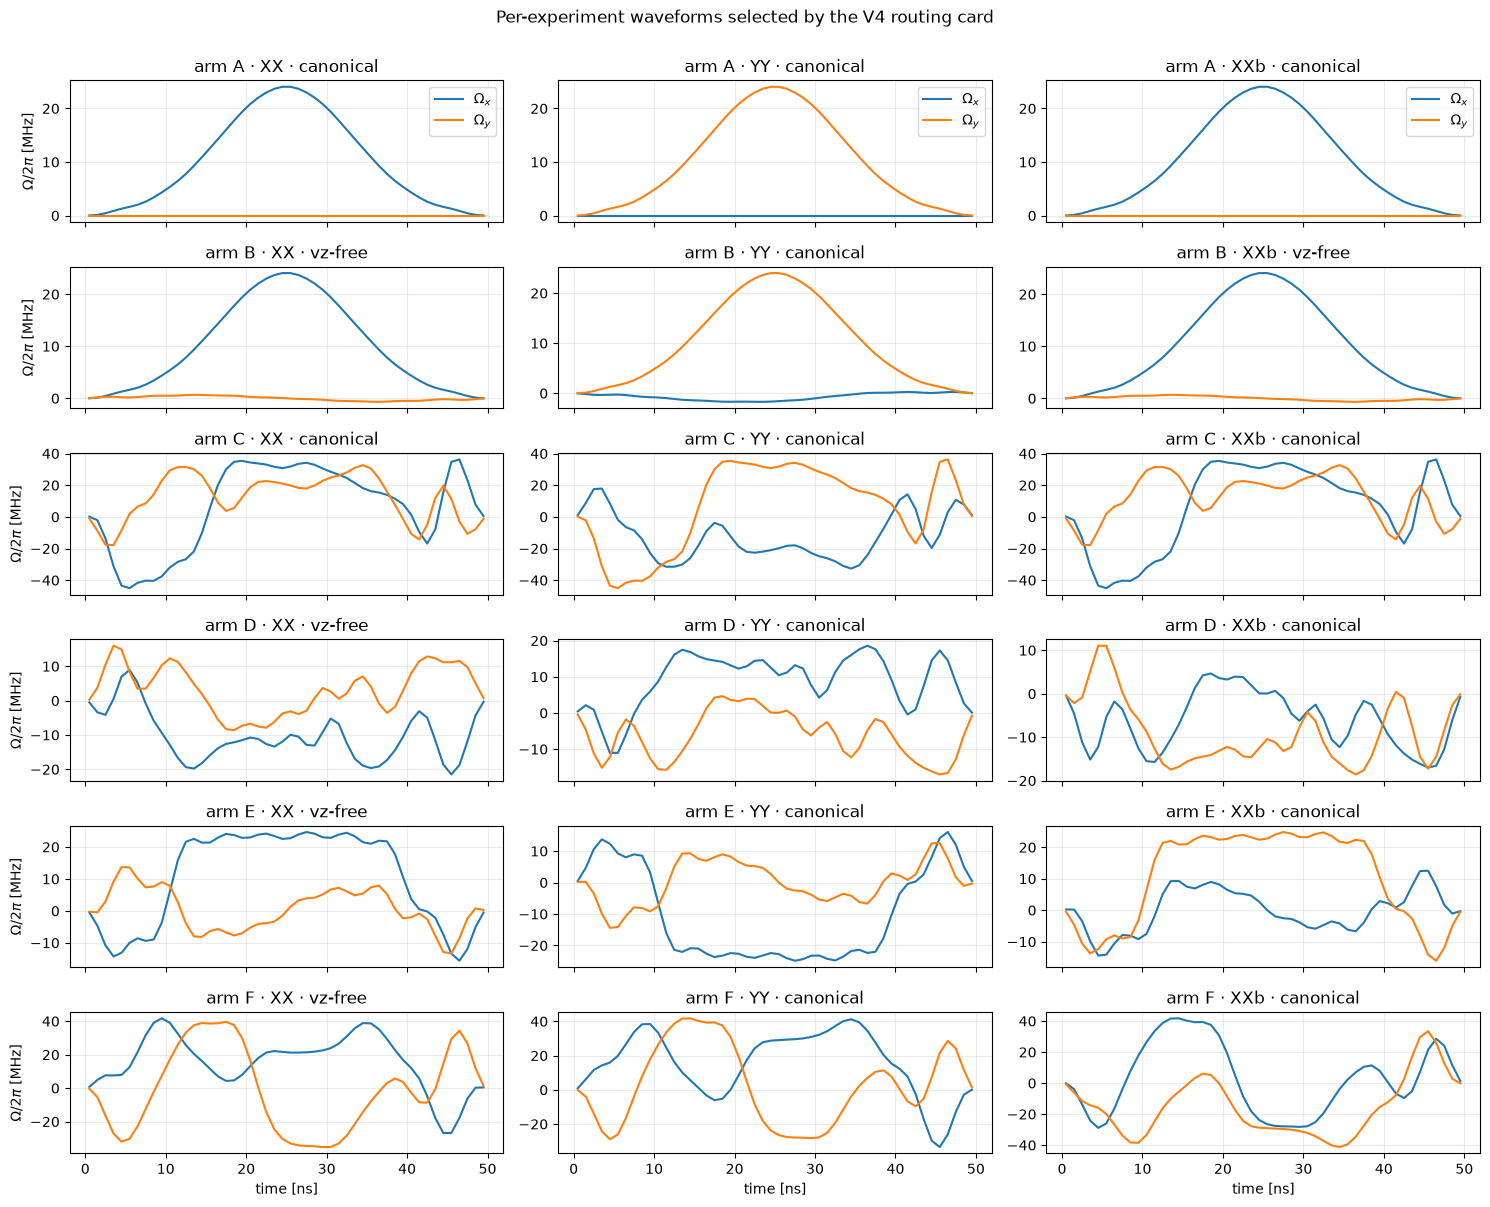

In [3]:
fig, axes = plt.subplots(len(ARMS), len(UNIT_ORDER), figsize=(15, 2.0 * len(ARMS)), sharex=True)
for row, arm in enumerate(ARMS):
    for col, unit in enumerate(UNIT_ORDER):
        waveform = SELECTED[arm][unit]
        variant_label = "vz-free" if ROUTING[arm][unit] == "vzfree" else "canonical"
        axis = axes[row, col]
        axis.plot(waveform["t_ns"], waveform["omega_x"] / (2 * np.pi) * 1e3, label=r"$\Omega_x$")
        axis.plot(waveform["t_ns"], waveform["omega_y"] / (2 * np.pi) * 1e3, label=r"$\Omega_y$")
        axis.set_title(f"arm {arm} · {unit} · {variant_label}")
        axis.grid(alpha=0.25)
        if row == 0:
            axis.legend(loc="upper right")
        if col == 0:
            axis.set_ylabel(r"$\Omega/2\pi$ [MHz]")
        if row == len(ARMS) - 1:
            axis.set_xlabel("time [ns]")
fig.suptitle("Per-experiment waveforms selected by the V4 routing card", y=1.002)
fig.tight_layout()
plt.show()

## DB experiment definition

For each arm, prepare $|+x\rangle$ and repeat one unit-cell channel
$n=0,\ldots,N$ times:

1. `XX`: $\mathcal E_X\circ\mathcal E_X$.
2. `YY`: $\mathcal E_Y\circ\mathcal E_Y$.
3. `XXb`: first $X$, then $X_b$, hence $\mathcal E_{X_b}\circ\mathcal E_X$.

The Hamiltonian is

$$
H=\operatorname{diag}(0,0,\Delta)
+\frac{\delta_z}{2}(I-2N)
+s(1+\epsilon)(\Omega_xD_X+\Omega_yD_Y),
$$

where $N=\operatorname{diag}(0,1,2)$ and $s=-1$ only for $X_b$. The master
equation uses collapse operators $\sqrt{\Gamma_1}a$ and
$\sqrt{2\Gamma_\phi}N$, with $\Gamma_\phi=1/T_{2,\rm echo}-1/(2T_1)$.
Thus `XXb` reverses only the **complete control term**; the bare Hamiltonian,
quasi-static $\delta_z$, relaxation, and dephasing all retain their signs/rates.

Each gate is a $9\times9$ column-stacking channel assembled from sample-and-hold
steps $\exp(\mathcal L\,dt)$, newest step on the left. The Liouvillian already
contains the Hamiltonian commutator, so it is never multiplied by an extra $-i$.

In [4]:
# Sequence length is the only free experiment knob in this notebook.
N_REPEATS = 100

# Both coherent-noise values come from the formal Novera Device loader.
# The same T1/T2 dissipation remains active in both settings.
NO_ERROR = "no_injected_error"
BOTH_ERRORS = "both_coherent_errors"
SETTINGS = {
    NO_ERROR: {"epsilon": 0.0, "delta_z": 0.0},
    BOTH_ERRORS: {
        "epsilon": float(NOVERA_DEVICE.control_error),
        "delta_z": float(NOVERA_DEVICE.static_detuning_rate),
    },
}
assert tuple(SETTINGS) == (NO_ERROR, BOTH_ERRORS)
assert len(SETTINGS) == 2
assert SETTINGS[NO_ERROR]["epsilon"] == SETTINGS[NO_ERROR]["delta_z"] == 0.0
assert SETTINGS[BOTH_ERRORS]["epsilon"] != 0.0 and SETTINGS[BOTH_ERRORS]["delta_z"] != 0.0
assert not any(
    (setting["epsilon"] == 0.0) ^ (setting["delta_z"] == 0.0)
    for setting in SETTINGS.values()
), "Amplitude and detuning errors must switch off/on together"

# Device quantities: angular rates are rad/ns, ordinary frequencies are GHz.
DELTA = float(NOVERA_DEVICE.delta)
assert np.isclose(DELTA, 2 * np.pi * float(DEVICE["anharmonicity_GHz"]))
DELTA_Z_ON = SETTINGS[BOTH_ERRORS]["delta_z"]
GHZ_TO_KHZ = 1e6
NS_TO_US = 1e-3
DETUNING_KHZ = float(NOVERA_DEVICE.static_detuning) * GHZ_TO_KHZ
assert np.isclose(DELTA_Z_ON / (2 * np.pi) * GHZ_TO_KHZ, DETUNING_KHZ)
DETUNING_LABEL = f"{DETUNING_KHZ:.0f} kHz"
assert DETUNING_LABEL == "100 kHz", DETUNING_LABEL

a = np.array([[0, 1, 0], [0, 0, np.sqrt(2)], [0, 0, 0]], dtype=complex)
DX = 0.5 * (a + a.conj().T)
DY = 0.5j * (a.conj().T - a)
NUMBER = np.diag([0.0, 1.0, 2.0]).astype(complex)
IDENTITY3 = np.eye(3, dtype=complex)
Z_LADDER = IDENTITY3 - 2.0 * NUMBER
PLUS = np.array([1.0, 1.0, 0.0], dtype=complex) / np.sqrt(2)
RHO_PLUS = np.outer(PLUS, PLUS.conj())
P_PLUS = RHO_PLUS.copy()

# Convention guards against curve_opt.qutip_sim.bare_hamiltonian.
assert np.array_equal(np.diag(Z_LADDER).real, np.array([1.0, -1.0, -3.0]))
assert np.allclose(
    np.diag(0.5 * DELTA_Z_ON * Z_LADDER),
    DELTA_Z_ON * np.array([0.5, -0.5, -1.5]),
    rtol=0.0,
    atol=np.finfo(float).eps,
)
assert np.allclose(
    qutip_sim.bare_hamiltonian(DELTA, DELTA_Z_ON).full(),
    np.diag([0.0, 0.0, DELTA]) + 0.5 * DELTA_Z_ON * Z_LADDER,
    rtol=0.0,
    atol=np.finfo(float).eps,
)

# Collapse operators are sourced from the verified QuTiP path and checked here.
C_OPS = qutip_sim.collapse_operators(NOVERA_DEVICE)
assert len(C_OPS) == 2
assert np.allclose(C_OPS[0].full(), np.sqrt(NOVERA_DEVICE.gamma1) * qt.destroy(3).full())
assert np.allclose(
    C_OPS[1].full(), np.sqrt(2.0 * NOVERA_DEVICE.gamma_phi) * qt.num(3).full()
)
L_CONTROL_X = np.asarray(qt.liouvillian(qutip_sim.DRIVE_X3).full())
L_CONTROL_Y = np.asarray(qt.liouvillian(qutip_sim.DRIVE_Y3).full())

print(
    "DB settings: dashed no injected control/detuning errors, T1/T2 on "
    "(epsilon=0, delta_z=0); "
    f"solid both coherent errors, T1/T2 on (epsilon={SETTINGS[BOTH_ERRORS]['epsilon']:.0%}, "
    f"delta_z/2pi={DETUNING_LABEL})"
)
print(
    f"Decoherence from formal Novera device: T1={NOVERA_DEVICE.t1 * NS_TO_US:g} us, "
    f"T2_echo={NOVERA_DEVICE.t2_echo * NS_TO_US:g} us"
)


def liouvillian_parts(delta_z):
    """Constant dissipative Liouvillian plus two linear control superoperators."""
    bare = qutip_sim.bare_hamiltonian(DELTA, delta_z)
    return {
        "constant": np.asarray(qt.liouvillian(bare, C_OPS).full()),
        "omega_x": L_CONTROL_X,
        "omega_y": L_CONTROL_Y,
    }


TRACE_ROW = IDENTITY3.ravel(order="F").conj()
TRACE_PRESERVATION_ERRORS = []


def apply_channel(channel, operator):
    """Apply a QuTiP/column-stacking 9x9 channel to a 3x3 operator."""
    vector = np.asarray(operator, dtype=complex).ravel(order="F")
    return (channel @ vector).reshape(3, 3, order="F")


def gate_channel(waveform, epsilon, delta_z, control_sign=1.0):
    """Three-level Lindblad channel for one sample-and-hold delivered gate."""
    parts = liouvillian_parts(delta_z)
    channel = np.eye(9, dtype=complex)
    amplitude = control_sign * (1.0 + epsilon)
    for omega_x, omega_y in zip(waveform["omega_x"], waveform["omega_y"]):
        generator = (
            parts["constant"]
            + amplitude * omega_x * parts["omega_x"]
            + amplitude * omega_y * parts["omega_y"]
        )
        step = expm(generator * waveform["dt_ns"])  # Liouvillian already includes -i[H, .]
        channel = step @ channel  # newest sample-and-hold step is on the left
    tp_error = float(np.max(np.abs(TRACE_ROW @ channel - TRACE_ROW)))
    TRACE_PRESERVATION_ERRORS.append(tp_error)
    assert tp_error < 5e-12, tp_error
    return channel


FINAL_STATE_DIAGNOSTICS = []


def db_trace(unit_channel, repeats=N_REPEATS):
    """Repeat a 9x9 unit-cell channel and read P_plus from a density matrix."""
    rho = RHO_PLUS.copy()
    p_plus = np.empty(repeats + 1)
    p_plus[0] = np.trace(P_PLUS @ rho).real
    for repeat in range(repeats):
        rho = apply_channel(unit_channel, rho)
        p_plus[repeat + 1] = np.trace(P_PLUS @ rho).real

    hermitian_error = float(np.max(np.abs(rho - rho.conj().T)))
    trace_error = float(abs(np.trace(rho) - 1.0))
    min_eigenvalue = float(np.min(np.linalg.eigvalsh(0.5 * (rho + rho.conj().T))))
    FINAL_STATE_DIAGNOSTICS.append((hermitian_error, trace_error, min_eigenvalue))
    assert hermitian_error < 5e-11, hermitian_error
    assert trace_error < 5e-11, trace_error
    assert min_eigenvalue > -5e-11, min_eigenvalue
    return p_plus


def traces_for_variant(arm, variant):
    """Compute dissipative XX, YY and XXb traces from one candidate variant."""
    traces = {unit: {} for unit in UNIT_ORDER}
    x_waveform = CANDIDATES["Xpi"][arm][variant]
    y_waveform = CANDIDATES["Ypi"][arm][variant]
    for setting_name, setting in SETTINGS.items():
        epsilon, delta_z = setting["epsilon"], setting["delta_z"]
        cx = gate_channel(x_waveform, epsilon, delta_z, control_sign=+1.0)
        cy = gate_channel(y_waveform, epsilon, delta_z, control_sign=+1.0)
        # Only the control term is reversed; bare/Z terms and C_OPS are unchanged.
        cxb = gate_channel(x_waveform, epsilon, delta_z, control_sign=-1.0)
        unit_cells = {
            "XX": cx @ cx,
            "YY": cy @ cy,
            "XXb": cxb @ cx,  # first X, then Xb
        }
        for unit, unit_channel in unit_cells.items():
            traces[unit][setting_name] = db_trace(unit_channel)
    return traces


VARIANT_TRACES = {
    arm: {variant: traces_for_variant(arm, variant) for variant in VARIANTS}
    for arm in ARMS
}
TRACES = {
    arm: {
        unit: VARIANT_TRACES[arm][ROUTING[arm][unit]][unit]
        for unit in UNIT_ORDER
    }
    for arm in ARMS
}
assert sum(len(TRACES[arm][unit]) for arm in ARMS for unit in UNIT_ORDER) == 6 * 3 * 2

tp_max = max(TRACE_PRESERVATION_ERRORS)
herm_max = max(item[0] for item in FINAL_STATE_DIAGNOSTICS)
trace_max = max(item[1] for item in FINAL_STATE_DIAGNOSTICS)
min_eval = min(item[2] for item in FINAL_STATE_DIAGNOSTICS)
print(f"Gate-channel trace-preservation max error: {tp_max:.3e}")
print(
    f"Final density checks ({len(FINAL_STATE_DIAGNOSTICS)} traces): "
    f"max Hermitian error={herm_max:.3e}, max trace error={trace_max:.3e}, "
    f"minimum eigenvalue={min_eval:.3e}"
)
print(f"Prepared {6 * 3 * 2} selected P_plus traces: 6 arms × 3 unit cells × 2 settings; T1/T2 on throughout.")

# Independent physical oracle: idle |+x> coherence decays with T2_echo.
idle_gate_time = float(DEVICE["gate_time_ns"])
idle_liouvillian = np.asarray(
    qt.liouvillian(qutip_sim.bare_hamiltonian(DELTA, 0.0), C_OPS).full()
)
idle_gate_channel = expm(idle_liouvillian * idle_gate_time)
idle_pair_channel = idle_gate_channel @ idle_gate_channel
idle_rho = RHO_PLUS.copy()
for _ in range(N_REPEATS):
    idle_rho = apply_channel(idle_pair_channel, idle_rho)
idle_duration = 2 * N_REPEATS * idle_gate_time
idle_pplus_numeric = float(np.trace(P_PLUS @ idle_rho).real)
idle_pplus_analytic = float(0.5 * (1.0 + np.exp(-idle_duration / NOVERA_DEVICE.t2_echo)))
assert abs(idle_pplus_numeric - idle_pplus_analytic) < 2e-12, (
    idle_pplus_numeric, idle_pplus_analytic
)
print(
    f"Independent idle oracle at t={idle_duration * NS_TO_US:g} us: "
    f"Pplus analytic={idle_pplus_analytic:.12f}, numeric={idle_pplus_numeric:.12f}, "
    f"abs diff={abs(idle_pplus_numeric - idle_pplus_analytic):.3e}"
)

DB settings: dashed no injected control/detuning errors, T1/T2 on (epsilon=0, delta_z=0); solid both coherent errors, T1/T2 on (epsilon=2%, delta_z/2pi=100 kHz)
Decoherence from formal Novera device: T1=35 us, T2_echo=41.9 us


Gate-channel trace-preservation max error: 2.221e-15
Final density checks (72 traces): max Hermitian error=9.655e-14, max trace error=3.949e-13, minimum eigenvalue=1.388e-04
Prepared 36 selected P_plus traces: 6 arms × 3 unit cells × 2 settings; T1/T2 on throughout.
Independent idle oracle at t=10 us: Pplus analytic=0.893839952143, numeric=0.893839952143, abs diff=2.220e-15


## Selected DB traces: $P_+$ versus repeated unit cells

One subplot is shown per arm. Colour identifies `XX`, `YY`, or `XXb`. The same
Novera $T_1/T_2$ decoherence is on in both line styles:

- dashed: **no injected control/detuning errors; T1/T2 on**
  ($\epsilon=0,\delta_z=0$);
- solid: **both coherent errors; T1/T2 on**
  ($\epsilon=+2\%,\delta_z/(2\pi)=+100\ \mathrm{kHz}$).

“No injected error” is only the coherent-error reference; it is not a
decoherence-free simulation. Each unit uses its independently routed CSV variant
from the opening card.

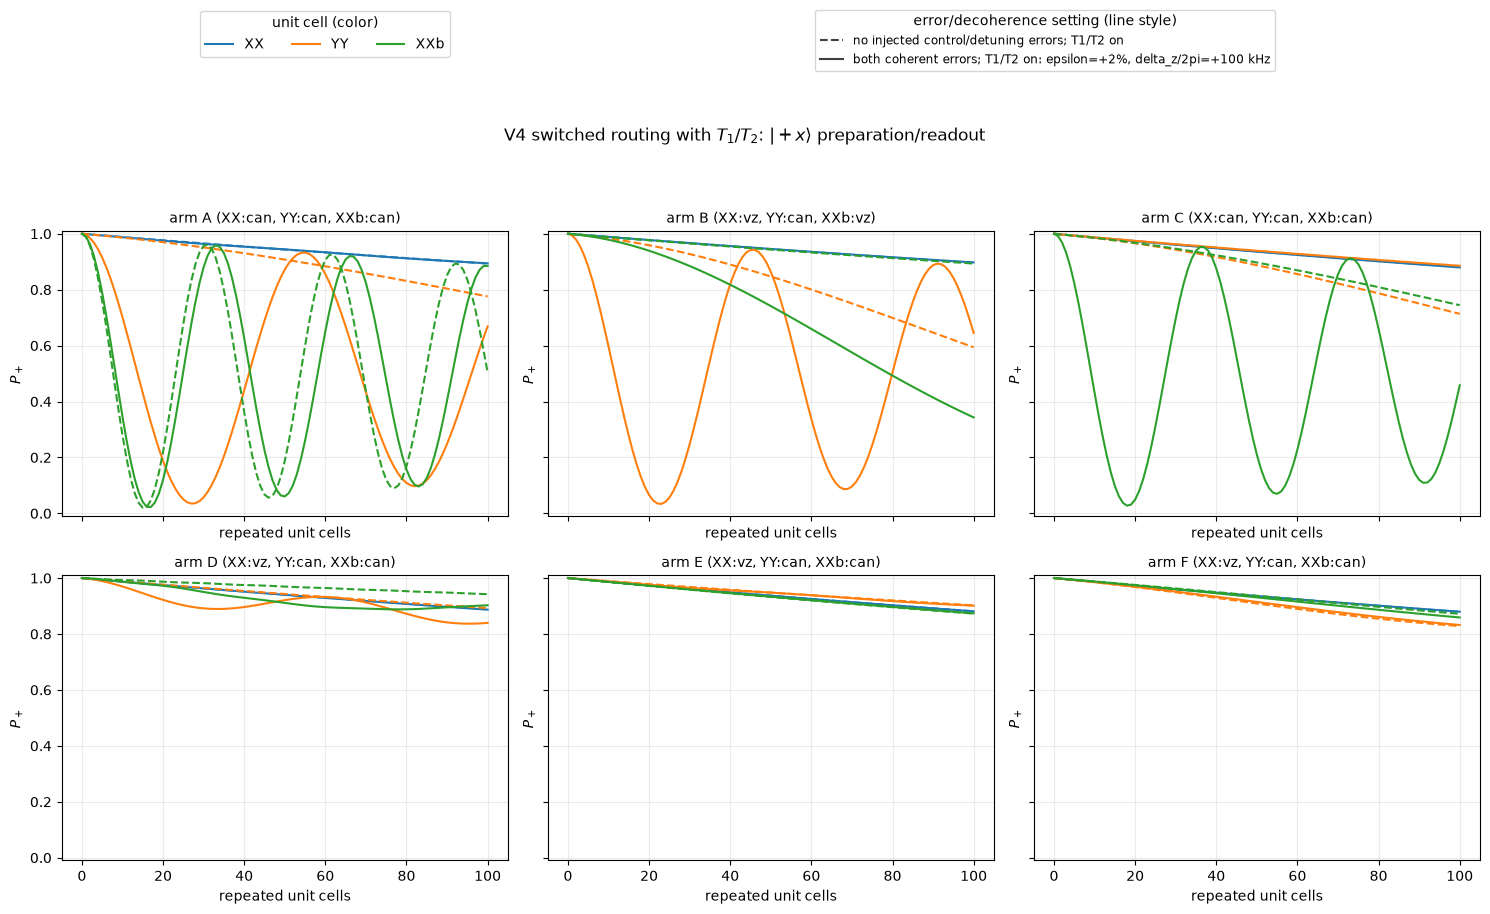

In [5]:
from matplotlib.lines import Line2D

repeats = np.arange(N_REPEATS + 1)
UNIT_COLORS = {"XX": "tab:blue", "YY": "tab:orange", "XXb": "tab:green"}
fig, axes = plt.subplots(2, 3, figsize=(15, 9.2), sharex=True, sharey=True)
for axis, arm in zip(axes.flat, ARMS):
    for unit in UNIT_ORDER:
        color = UNIT_COLORS[unit]
        axis.plot(repeats, TRACES[arm][unit][NO_ERROR], "--", color=color)
        axis.plot(repeats, TRACES[arm][unit][BOTH_ERRORS], "-", color=color)
    route_summary = ", ".join(
        f"{unit}:{'vz' if ROUTING[arm][unit] == 'vzfree' else 'can'}" for unit in UNIT_ORDER
    )
    axis.set_title(f"arm {arm} ({route_summary})", fontsize=10)
    axis.set_xlabel("repeated unit cells")
    axis.set_ylabel(r"$P_+$")
    axis.set_ylim(-0.01, 1.01)
    axis.grid(alpha=0.25)

unit_handles = [Line2D([], [], color=UNIT_COLORS[name], label=name) for name in UNIT_ORDER]
setting_handles = [
    Line2D(
        [], [], color="0.25", linestyle="--",
        label="no injected control/detuning errors; T1/T2 on",
    ),
    Line2D(
        [], [], color="0.25", linestyle="-",
        label=(
            f"both coherent errors; T1/T2 on: epsilon={SETTINGS[BOTH_ERRORS]['epsilon']:+.0%}, "
            f"delta_z/2pi=+{DETUNING_LABEL}"
        ),
    ),
]
fig.legend(
    unit_handles, [handle.get_label() for handle in unit_handles],
    title="unit cell (color)", loc="upper center", bbox_to_anchor=(0.22, 0.995), ncol=3,
)
fig.legend(
    setting_handles, [handle.get_label() for handle in setting_handles],
    title="error/decoherence setting (line style)", loc="upper center",
    bbox_to_anchor=(0.70, 0.995), ncol=1, fontsize=8.5,
)
fig.suptitle(r"V4 switched routing with $T_1/T_2$: $|+x\rangle$ preparation/readout", y=0.86)
fig.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

## Selection audit

The audit recomputes each candidate's score from the two **dissipative** traces:
`(epsilon=0, delta_z=0; T1/T2 on)` and
`(epsilon=+2%, delta_z/2pi=+100 kHz; T1/T2 on)`. It prints the selected and
alternative scores for all 18 `(arm, unit)` cases, independently derives the
minimum-score choice with the stated $10^{-9}$ canonical tie rule, and asserts that
both the static route and `chosen_score <= alternative_score + 1e-9` hold.

In [6]:
SCORE_TIE_TOL = 1e-9


def trace_score(traces):
    """Largest peak-to-peak P_plus range across the two coupled settings."""
    return max(float(np.ptp(traces[setting_name])) for setting_name in SETTINGS)


AUDIT = {arm: {} for arm in ARMS}
print(
    "Selection audit with T1/T2 on: score = max[ptp(no injected errors), ptp(both coherent errors: "
    f"epsilon={SETTINGS[BOTH_ERRORS]['epsilon']:.0%}, delta_z/2pi={DETUNING_LABEL})]"
)
for arm in ARMS:
    for unit in UNIT_ORDER:
        scores = {
            variant: trace_score(VARIANT_TRACES[arm][variant][unit])
            for variant in VARIANTS
        }
        chosen = ROUTING[arm][unit]
        alternative = "vzfree" if chosen == "canonical" else "canonical"
        if abs(scores["canonical"] - scores["vzfree"]) <= SCORE_TIE_TOL:
            derived_choice = "canonical"
        else:
            derived_choice = min(scores, key=scores.get)
        assert derived_choice == chosen, (arm, unit, scores, derived_choice, chosen)
        assert scores[chosen] <= scores[alternative] + SCORE_TIE_TOL, (arm, unit, scores)
        AUDIT[arm][unit] = {"chosen": chosen, "alternative": alternative, "scores": scores}
        print(
            f"  {arm} {unit:3s}: chosen {chosen:9s} {scores[chosen]:.12e} | "
            f"alternative {alternative:9s} {scores[alternative]:.12e}"
        )
print("All 18 static routes satisfy the dissipative combined-error score rule and tolerance.")

Selection audit with T1/T2 on: score = max[ptp(no injected errors), ptp(both coherent errors: epsilon=2%, delta_z/2pi=100 kHz)]
  A XX : chosen canonical 1.065819528591e-01 | alternative vzfree    1.065819528590e-01
  A YY : chosen canonical 9.650088573242e-01 | alternative vzfree    9.650088573199e-01
  A XXb: chosen canonical 9.795130297127e-01 | alternative vzfree    9.795130297127e-01
  B XX : chosen vzfree    1.036408099469e-01 | alternative canonical 1.050178016350e-01
  B YY : chosen canonical 9.661656246098e-01 | alternative vzfree    9.704194333246e-01
  B XXb: chosen vzfree    6.567342244800e-01 | alternative canonical 6.569787476141e-01
  C XX : chosen canonical 1.204508987361e-01 | alternative vzfree    1.204882237548e-01
  C YY : chosen canonical 2.864599532539e-01 | alternative vzfree    2.868442963852e-01
  C XXb: chosen canonical 9.725028320950e-01 | alternative vzfree    9.765931996967e-01
  D XX : chosen vzfree    1.129905476342e-01 | alternative canonical 8.883937236

## Reading the result

Compare the solid and dashed curves within one arm/unit. Their separation is the
response to switching the amplitude and quasi-static-Z errors **on together**.
$T_1/T_2$ decoherence remains present in both, so the dashed “no injected error”
trace can still decay and is **not** a coherent-only or decoherence-free baseline.
This notebook contains no amplitude-only, detuning-only, coherent-only, or SPAM trace.

The routing selection minimises the **absolute peak-to-peak oscillation** over the
two dissipative traces, not their separation and not gate infidelity. Consequently,
a selected trace may still oscillate strongly; the opening routing card is an
operational CSV-selection guide, not a claim that every experiment becomes flat.